# How historic is the July 2026 wildfire smoke event?

### A multi-year AirNow PM$_{2.5}$ analysis for Chicago-area monitors

In mid-July 2026, smoke from record Canadian wildfires (primarily northwestern Ontario)
was transported across the Upper Midwest, driving surface fine-particulate (PM$_{2.5}$)
concentrations in the Chicago area to extreme levels. This notebook asks a simple question:

> **How unusual is this event in the historical record?**

To answer it, we pull the **entire AirNow archive** for two suburban Chicago monitors —
**Northbrook** and **Naperville, IL** — going back to 2010, and rank the July 2026 event
against ~16 years of hourly observations.

**Author:** Scott Collis · **Co-author:** Claude (Anthropic)

---
*Data source: [AirNow API](https://docs.airnowapi.org/). Requires a free API key set in the
`AIRNOW_API` environment variable.*

## 1 · Setup

All configuration lives here. The event date is pinned so the notebook reproduces the same result in the future.

In [1]:
import os, json, time, calendar, urllib.request, urllib.parse
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.patches import Patch

# --- API key from environment (never hard-code it) ---
AIRNOW_KEY = os.environ["AIRNOW_API"]

# --- pinned analysis window ---
ARCHIVE_START = 2010            # first year to attempt
ARCHIVE_END   = 2026            # last year (through July)
EVENT_START   = "2026-07-14"    # start of the July 2026 smoke episode
CENTRAL       = ZoneInfo("America/Chicago")

# --- sites: name -> (lat, lon, tight bbox isolating the monitor, agency) ---
SITES = {
    "Northbrook, IL": dict(lat=42.1406, lon=-87.7994,
                           bbox="-87.859,42.041,-87.740,42.241", agency="Illinois EPA"),
    "Naperville, IL": dict(lat=41.7714, lon=-88.1522,
                           bbox="-88.19,41.72,-88.11,41.82",    agency="Illinois EPA"),
}

# --- EPA PM2.5 breakpoints (24-h-style bands, used for shading) ---
EPA_BANDS = [(0,12,"#2c7fb8","Good"), (12,35.4,"#fdae61","Moderate"),
             (35.4,55.4,"#d7301f","Unhealthy (SG)"), (55.4,150.4,"#7a0177","Unhealthy"),
             (150.4,600,"#4d004b","Hazardous")]
print("configured sites:", list(SITES))

configured sites: ['Northbrook, IL', 'Naperville, IL']


## 2 · Pulling the AirNow archive

AirNow serves historical hourly data, but a single request covers only a limited time span
before it times out. The practical unit is **one calendar month per call** (~30 s each), so
~16 years is ~200 requests. We pull them concurrently (6 workers) with retries, and **cache
the assembled series to CSV** — the first run takes ~45 minutes per site; subsequent runs load
instantly from the cache.

In [1]:
def airnow_month(bbox, start, end, timeout=150):
    """One monthly PM2.5 pull (dataType='C' = concentration, verbose=0, all monitors)."""
    q = urllib.parse.urlencode({
        "startDate": start, "endDate": end, "parameters": "PM25", "BBOX": bbox,
        "dataType": "C", "format": "application/json",
        "verbose": 0, "monitorType": 0, "API_KEY": AIRNOW_KEY})
    with urllib.request.urlopen("https://www.airnowapi.org/aq/data/?" + q, timeout=timeout) as r:
        return json.load(r)

def month_ranges(y0, y1):
    out = []
    for yr in range(y0, y1 + 1):
        for mo in range(1, 13):
            if yr == y1 and mo > 7:      # data through July of the final year
                break
            last = calendar.monthrange(yr, mo)[1]
            out.append((f"{yr}-{mo:02d}-01T00", f"{yr}-{mo:02d}-{last:02d}T23"))
    return out

def pull_history(name, cfg, cache_dir="."):
    """Pull the full hourly PM2.5 record for one site, with CSV caching."""
    slug  = name.split(",")[0].strip().lower().replace(" ", "_")
    cache = os.path.join(cache_dir, f"{slug}_pm25_hourly_2010_2026.csv")
    if os.path.exists(cache):
        df = pd.read_csv(cache, parse_dates=["utc"])
        print(f"{name}: loaded {len(df):,} hourly obs from cache")
        return df

    ranges = month_ranges(ARCHIVE_START, ARCHIVE_END)
    print(f"{name}: pulling {len(ranges)} months (this takes ~45 min the first time)...")
    raw = {}
    def one(rng):
        s, e = rng
        for attempt in range(3):
            try:    return rng, airnow_month(cfg["bbox"], s, e)
            except Exception:
                if attempt == 2: return rng, []
                time.sleep(5)
    with ThreadPoolExecutor(max_workers=6) as ex:
        for fut in as_completed([ex.submit(one, r) for r in ranges]):
            rng, recs = fut.result(); raw[rng] = recs

    rows = [(r["UTC"], r["Value"]) for recs in raw.values() if isinstance(recs, list)
            for r in recs if r.get("Value") is not None and r["Value"] >= 0]
    df = (pd.DataFrame(rows, columns=["utc", "pm25"])
            .assign(utc=lambda d: pd.to_datetime(d["utc"]))
            .drop_duplicates("utc").sort_values("utc").reset_index(drop=True))
    df.to_csv(cache, index=False)
    print(f"{name}: pulled & cached {len(df):,} hourly obs")
    return df

In [1]:
records = {name: pull_history(name, cfg) for name, cfg in SITES.items()}
for name, df in records.items():
    df["year"] = df["utc"].dt.year
    df["date"] = df["utc"].dt.date
    print(f"{name}: {len(df):,} obs | {df['utc'].min()} -> {df['utc'].max()} "
          f"| {df['pm25'].min():.0f}-{df['pm25'].max():.0f} ug/m3")

Northbrook, IL: loaded 121,078 hourly obs from cache
Naperville, IL: loaded 103,054 hourly obs from cache
Northbrook, IL: 121,078 obs | 2010-01-01 07:00:00 -> 2026-07-17 14:00:00 | 0-536 ug/m3
Naperville, IL: 103,054 obs | 2010-01-01 07:00:00 -> 2026-07-17 15:00:00 | 0-466 ug/m3


## 3 · Ranking the July 2026 event

For each site we compute how the current event compares to the full record:

- **All-time hourly maximum** and its percentile among all hours on record
- **Top-10 worst days** by 24-hour mean PM$_{2.5}$
- **Hazardous hours** (>150.4 µg/m³) in this event vs. all prior years
- **Long-term baseline** (median / mean) for context

In [1]:
def epa_cat(v):
    for lo, hi, _, nm in EPA_BANDS:
        if v <= hi: return nm
    return "Hazardous"

def rank_event(name, df):
    ev  = pd.Timestamp(EVENT_START)
    cur = df[df["utc"] >= ev]
    prior = df[df["utc"] < ev]
    pk = df["pm25"].max(); pk_when = df.loc[df["pm25"].idxmax(), "utc"]

    daily = (df.groupby("date")["pm25"].agg(["mean", "max", "count"]).reset_index())
    daily = daily[daily["count"] >= 18].sort_values("mean", ascending=False).reset_index(drop=True)

    prev = prior["pm25"].max()
    haz_now = int((cur["pm25"] > 150.4).sum())
    haz_prior = int((prior["pm25"] > 150.4).sum())

    print(f"\n===== {name} =====")
    print(f"All-time hourly max : {pk:.1f} ug/m3 at {pk_when}")
    print(f"  percentile        : {100*(df['pm25'] < pk).mean():.4f}th of {len(df):,} hours")
    print(f"Previous record     : {prev:.1f} ug/m3  ->  current is {pk/prev:.1f}x higher")
    print(f"Hazardous hours     : {haz_now} in this event vs {haz_prior} in all prior years")
    print(f"Baseline (pre-event): median {prior['pm25'].median():.1f}, mean {prior['pm25'].mean():.1f} ug/m3")
    print(f"Event mean          : {cur['pm25'].mean():.1f} ug/m3 "
          f"(~{cur['pm25'].mean()/prior['pm25'].mean():.0f}x the long-term mean)")
    print("Top-5 worst days by 24-h mean:")
    for i, r in daily.head(5).iterrows():
        print(f"  {i+1}. {r['date']}  mean {r['mean']:6.1f}  max {r['max']:6.1f}")
    return dict(cur=cur, daily=daily, peak=pk, peak_when=pk_when,
                annual=df.groupby("year")["pm25"].max())

ranks = {name: rank_event(name, df) for name, df in records.items()}


===== Northbrook, IL =====
All-time hourly max : 535.6 ug/m3 at 2026-07-16 21:00:00
  percentile        : 99.9992th of 121,078 hours
Previous record     : 206.4 ug/m3  ->  current is 2.6x higher
Hazardous hours     : 29 in this event vs 9 in all prior years
Baseline (pre-event): median 7.5, mean 9.0 ug/m3
Event mean          : 131.6 ug/m3 (~15x the long-term mean)
Top-5 worst days by 24-h mean:
  1. 2026-07-16  mean  255.0  max  535.6
  2. 2023-06-28  mean  141.3  max  157.3
  3. 2023-06-27  mean  112.8  max  181.1
  4. 2023-06-29  mean  101.0  max  141.2
  5. 2015-07-05  mean   72.8  max  206.4

===== Naperville, IL =====
All-time hourly max : 465.9 ug/m3 at 2026-07-17 05:00:00
  percentile        : 99.9990th of 103,054 hours
Previous record     : 208.3 ug/m3  ->  current is 2.2x higher
Hazardous hours     : 22 in this event vs 35 in all prior years
Baseline (pre-event): median 8.8, mean 10.2 ug/m3
Event mean          : 98.4 ug/m3 (~10x the long-term mean)
Top-5 worst days by 24-h me

## 4 · Historic-context figure

A three-panel view per site: **(top-left)** annual peak hourly PM$_{2.5}$ as a lollipop chart,
**(top-right)** the ten worst days ranked by 24-hour mean, and **(bottom)** the hourly trace of
the July 2026 event itself, shaded by EPA air-quality category in local (CDT) time.

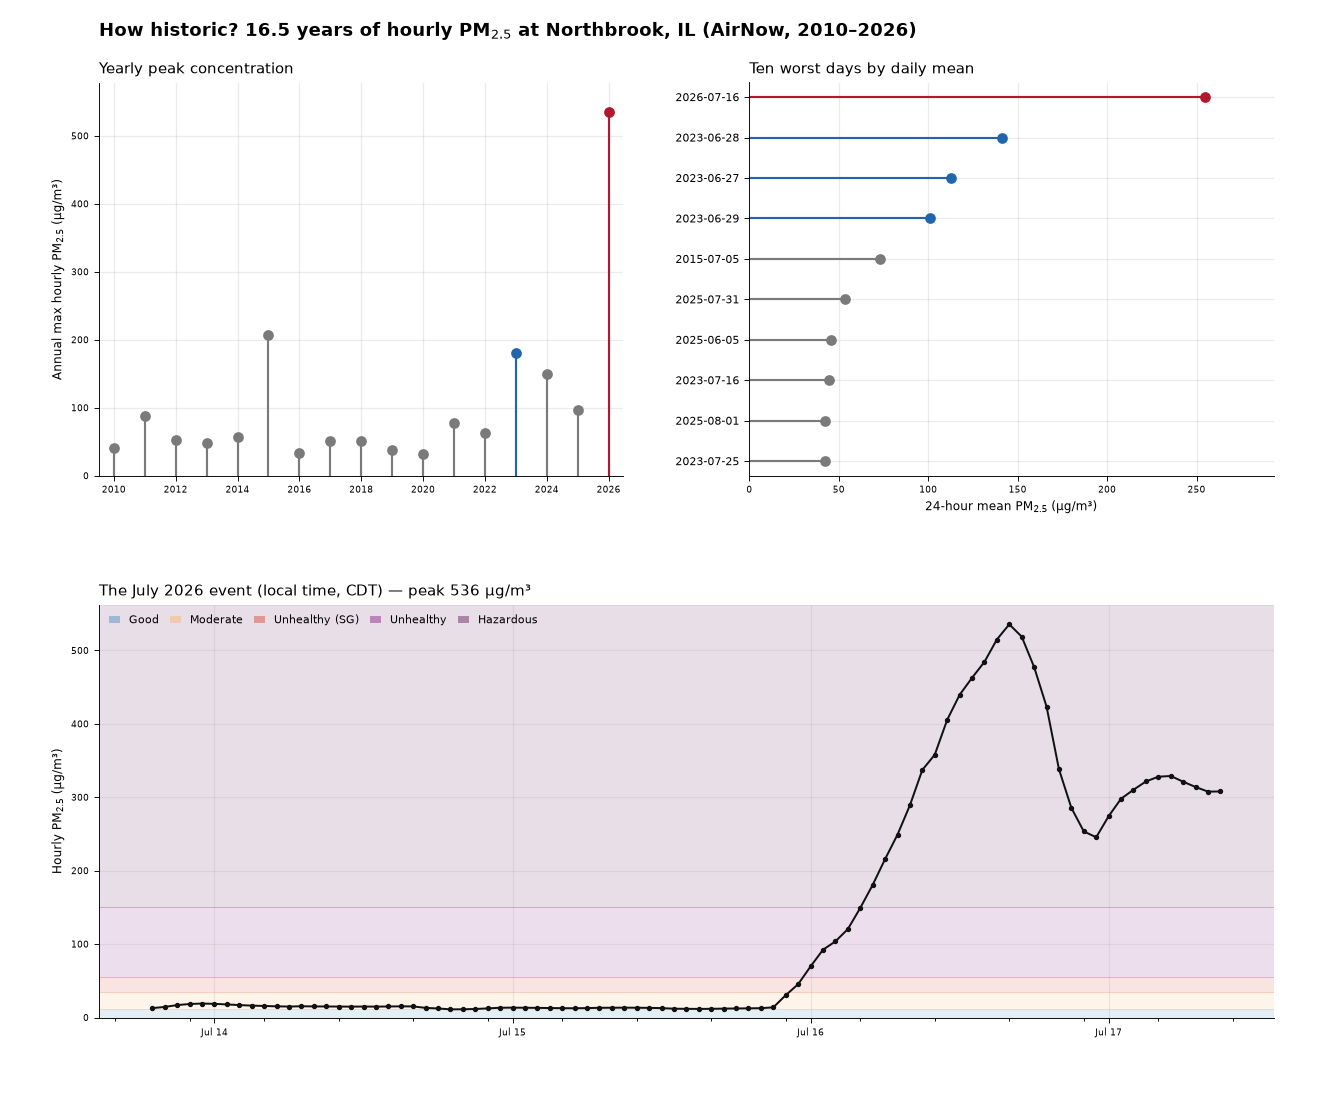

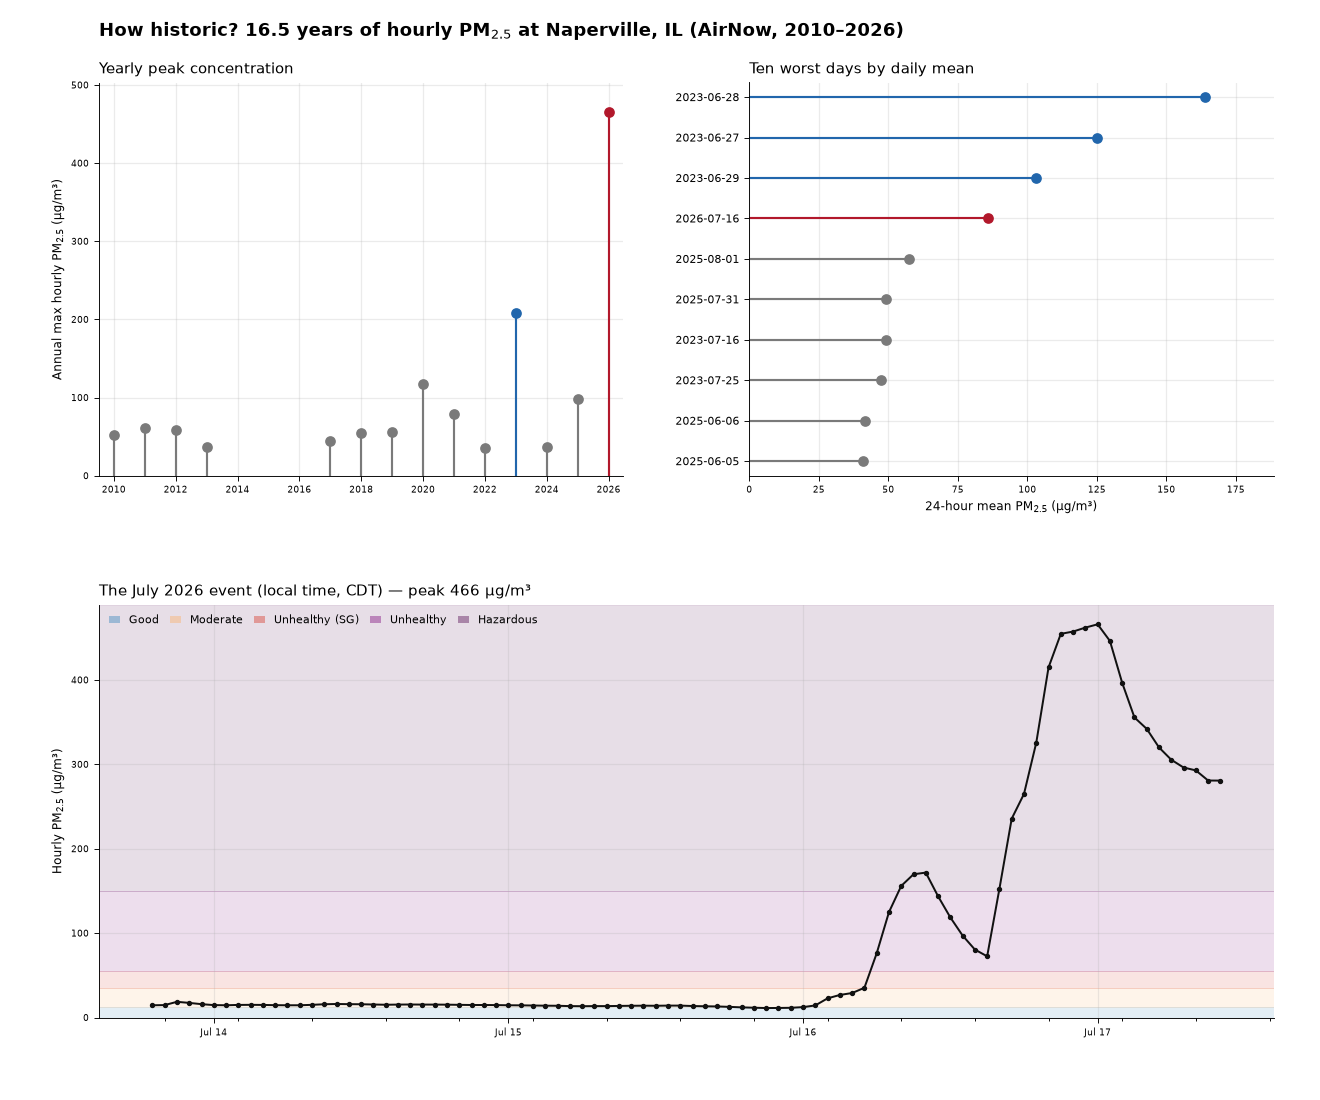

In [1]:
plt.rcParams.update({"font.size": 9, "axes.titlesize": 10, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True, "savefig.bbox": "standard"})
FOCAL, C2023, NEUTRAL = "#b2182b", "#2166ac", "#7a7a7a"

def historic_figure(name, df, R):
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], hspace=0.32, wspace=0.24,
                          left=0.075, right=0.965, top=0.925, bottom=0.075)
    axA, axB, axC = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,:])

    # Panel A: annual peak lollipop
    ann = R["annual"]; yrs = ann.index.astype(int).values; pks = ann.values
    ymaxA = max(pks) * 1.08
    for y, p in zip(yrs, pks):
        c = FOCAL if y == 2026 else (C2023 if y == 2023 else NEUTRAL)
        axA.plot([y, y], [0, p], color=c, lw=1.4, zorder=2); axA.plot(y, p, "o", color=c, ms=6, zorder=3)
    axA.set_ylim(0, ymaxA); axA.set_ylabel("Annual max hourly PM$_{2.5}$ (µg/m³)")
    axA.set_title("Yearly peak concentration", loc="left"); axA.margins(x=0.03)

    # Panel B: top-10 daily means
    top = R["daily"].head(10).iloc[::-1].reset_index(drop=True)
    for i, (m, d) in enumerate(zip(top["mean"], top["date"])):
        ds = str(d); c = FOCAL if ds.startswith("2026") else (C2023 if ds.startswith("2023-06") else NEUTRAL)
        axB.plot([0, m], [i, i], color=c, lw=1.4, zorder=2); axB.plot(m, i, "o", color=c, ms=6, zorder=3)
    axB.set_yticks(range(len(top))); axB.set_yticklabels([str(d) for d in top["date"]], fontsize=7)
    axB.set_xlabel("24-hour mean PM$_{2.5}$ (µg/m³)"); axB.set_xlim(0, top["mean"].max()*1.15)
    axB.set_title("Ten worst days by daily mean", loc="left"); axB.margins(y=0.04)

    # Panel C: current event trace
    cur = R["cur"].copy()
    cur["local"] = cur["utc"].dt.tz_localize("UTC").dt.tz_convert(CENTRAL)
    ymaxC = max(R["peak"]*1.05, 60)
    for lo, hi, col, _ in EPA_BANDS: axC.axhspan(lo, min(hi, ymaxC), color=col, alpha=0.13, zorder=0)
    axC.plot(cur["local"], cur["pm25"], "-o", color="#111", ms=2.5, lw=1.3, zorder=3)
    axC.set_ylim(0, ymaxC); axC.set_ylabel("Hourly PM$_{2.5}$ (µg/m³)")
    axC.xaxis.set_major_locator(mdates.DayLocator(tz=CENTRAL))
    axC.xaxis.set_major_formatter(mdates.DateFormatter("%b %-d", tz=CENTRAL))
    axC.xaxis.set_minor_locator(mdates.HourLocator(interval=6, tz=CENTRAL))
    axC.set_title(f"The July 2026 event (local time, CDT) — peak {R['peak']:.0f} µg/m³", loc="left")
    axC.legend(handles=[Patch(facecolor=c, alpha=0.4, label=n) for _,_,c,n in EPA_BANDS],
               loc="upper left", ncol=5, frameon=False, fontsize=7, handlelength=1.1, columnspacing=1.0)

    fig.suptitle(f"How historic? 16.5 years of hourly PM$_{{2.5}}$ at {name} (AirNow, 2010–2026)",
                 fontsize=12, fontweight="bold", x=0.075, ha="left")
    return fig

for name, df in records.items():
    fig = historic_figure(name, df, ranks[name])
    plt.show()

## 5 · Findings

**Northbrook, IL** — July 2026 is unprecedented on *every* metric. The all-time hourly maximum
(≈536 µg/m³) was set during the event, and **July 16 averaged ≈255 µg/m³ over 24 hours — nearly
double the previous worst day** (June 28, 2023, at ≈141 µg/m³, the earlier Canadian-smoke episode).
The event produced far more Hazardous-category hours than all prior years on record combined.

**Naperville, IL** (~35 km southwest) — a more nuanced picture. The event set a new **hourly**
record (≈466 µg/m³, about 2.2× the prior peak), but on a **24-hour-mean** basis it ranks only
4th: the **June 2023** episode was worse here, with daily means of ≈164, 125, and 103 µg/m³ on
June 27–29. The July 2026 spike was more intense but shorter-lived at this site.

**Takeaway.** Both monitors set new hourly records in July 2026, confirming an exceptional
short-duration smoke intrusion. The contrast in *sustained* exposure — unprecedented at Northbrook,
second-worst at Naperville — shows how sharply the densest part of the plume was localized, even
across neighbouring suburbs. Extending this workflow to additional monitors (just add entries to
`SITES`) would map that gradient in detail.